In [ ]:
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
from scipy.special import eval_legendre
from astropy.io import fits
import os
import time

In [ ]:
# Set seed for reproducibility seed =42
np.random.seed(50)

### Anchored Correlation maps 

In [ ]:
def get_anchored_correlation(map, alpha, beta, gamma):

    """Compute the C_001(psi, phi) correlation function for a map, by averaging over n anchor points by random rotation angles"""
    Anchored_correlation = np.zeros_like(map)
    nside = hp.get_nside(map)
    n_anchors = len(gamma)
    
    for i in range(n_anchors):
        if i % 200 == 0:
            print(f"Rotated Sky Map {i}: alpha={alpha[i]}, beta={beta[i]}, gamma={gamma[i]}")
        # t0 = time.perf_counter()
        rotation= hp.rotator.Rotator( rot = [alpha[i], beta[i], gamma[i]], deg =False)
        # t1 = time.perf_counter()
        rotated_map = rotation.rotate_map_pixel(map)
        # t2 = time.perf_counter()
        T_001 = rotated_map[hp.ang2pix(nside, 0, 0)]
        # t3 = time.perf_counter()
        Anchored_correlation += T_001 * rotated_map
        # t4 = time.perf_counter()
        if i>0 and i%10000 ==0:
            output_filename = f"correlation_map_{nside}_{i}.fits"
            hp.write_map(output_filename, Anchored_correlation/i, overwrite=True)
            print(f" Correlation Map saved as {output_filename}")
            previous_file = f"correlation_map_{nside}_{i-1000}.fits"
            if os.path.exists(previous_file):
                os.remove(previous_file)
                print(f" Removed {previous_file}")
        # print(f"Timing for iteration {i}:")
        # print(f"  Rotator creation: {t1 - t0:.4f} s")
        # print(f"  Map rotation: {t2 - t1:.4f} s")
        # print(f"  T_001 extraction: {t3 - t2:.4f} s")
        # print(f"  Correlation computation: {t4 - t3:.4f} s")
        # print("=" * 40)


    return Anchored_correlation / len(gamma)

In [ ]:
def get_anchored_correlation2(map, anchors):

    """Compute the C_001(psi, phi) correlation function for a map, by averaging over n anchor points."""
    Anchored_correlation = np.zeros_like(map)
    nside = hp.get_nside(map)
    n_anchors = len(anchors)
    
    # print(nside, anchors)
    
    theta_anchors, phi_anchors = hp.pix2ang(nside, anchors, lonlat = False)  # Get anchor points

    # Calculate the angles for rotation of anchor point to z-axis
    omega = -theta_anchors
    Theta = np.pi / 2

    # Phi is given by the inverse tangent, but for spherical coordinates we already have it from phi1
    # if phi_anchors <= np.pi:    #     Phi = np.arctan(-1/np.tan(phi_anchors)) + np.pi # else:    #     Phi = np.arctan(-1/np.tan(phi_anchors))
    Phi = np.where(phi_anchors <= np.pi,   
                np.arctan(-1/np.tan(phi_anchors)) + np.pi, 
                np.arctan(-1/np.tan(phi_anchors)))

    # Now calculate the Euler angles:
    alpha = Phi - np.pi/2
    beta = -theta_anchors # omega
    gamma = np.zeros_like(alpha)  #-alpha

    for i in range(n_anchors):

        if i % 200 == 0:
            print(f"Rotated Sky Map {i}: alpha={alpha[i]}, beta={beta[i]}, gamma={gamma[i]}")

        rotation= hp.rotator.Rotator( rot = [alpha[i], beta[i], gamma[i]], deg =False)

        rotated_map = rotation.rotate_map_pixel(map)

        T_001 = rotated_map[hp.ang2pix(nside, 0, 0)]
        Anchored_correlation += T_001 * rotated_map

        if i == 0:
            hp.mollview(map, title="Original Sky Map", unit="K", norm="hist", cmap = "coolwarm")
            hp.graticule()
            hp.projscatter(theta_anchors[i], phi_anchors[i], marker='*', color='black', s=100, label= "Anchor Point original")
            plt.legend()
            plt.show()
            theta_rot, phi_rot = rotation((theta_anchors[i], phi_anchors[i]))
            hp.mollview(rotated_map, title="Rotated Sky Map", unit="K", norm="hist", cmap = "coolwarm")
            hp.graticule()
            hp.projscatter(0, 0, marker='*', color='red', s=100)
            hp.projscatter(theta_rot, phi_rot, marker='*', color='black', s=100, label= "Anchor Point after Rotation")
            plt.legend()
            plt.show()

        if i>0 and i%10000 ==0:
            output_filename = f"correlation_map_{nside}_{i}.fits"
            hp.write_map(output_filename, Anchored_correlation/i, overwrite=True)
            print(f" Correlation Map saved as {output_filename}")
            previous_file = f"correlation_map_{nside}_{i-1000}.fits"
            if os.path.exists(previous_file):
                os.remove(previous_file)
                print(f" Removed {previous_file}")


    return Anchored_correlation / len(gamma)

In [ ]:
def get_C001_from_maps(map):

    "Here the given map is the Spatially Averaged correlation map produced earlier"
    nside = hp.get_nside(map)
    theta_all, phi_all = hp.pix2ang(nside, np.arange(hp.nside2npix(nside))) # Get pixel angles

    unique_theta = np.unique(theta_all)  # Get unique theta values
    num_unique_theta = len(unique_theta)  # Count unique values

    print(f"Number of distinct theta values: {num_unique_theta}")
    print(f"Unique theta values: {unique_theta}")


    C_0001_EA = np.zeros_like(unique_theta) # Array to store the C_001 values

    for i, theta in enumerate(unique_theta):
        same_theta_pixels = np.where(theta_all == theta)[0]
        C_0001_EA[i] = np.mean(map[same_theta_pixels])  

    return unique_theta, C_0001_EA

## Reading Planck data


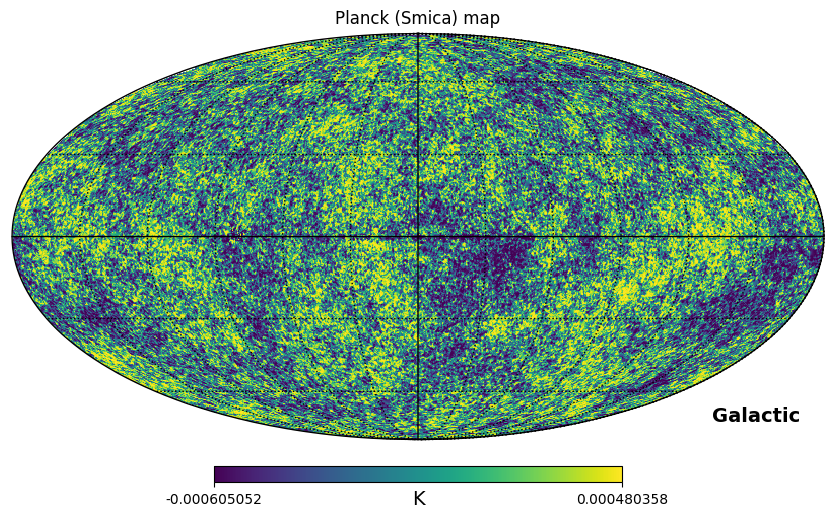

In [ ]:
# Path to the FITS file
fits_file_path = f'{os.getcwd()}/Data/CMB-Planck_Smica_nosz_map_2048_R3.fits'
# fits_file_path = f'{os.getcwd()}/Data/galactic_output_map_1.fits'

Planck_Smica_map = hp.read_map(fits_file_path, field =0)

hp.mollview(
    Planck_Smica_map,
    coord=["G"],
    title="Planck (Smica) map",
    unit="K",
    norm="hist",
    # cmap = "coolwarm",
)
hp.graticule()

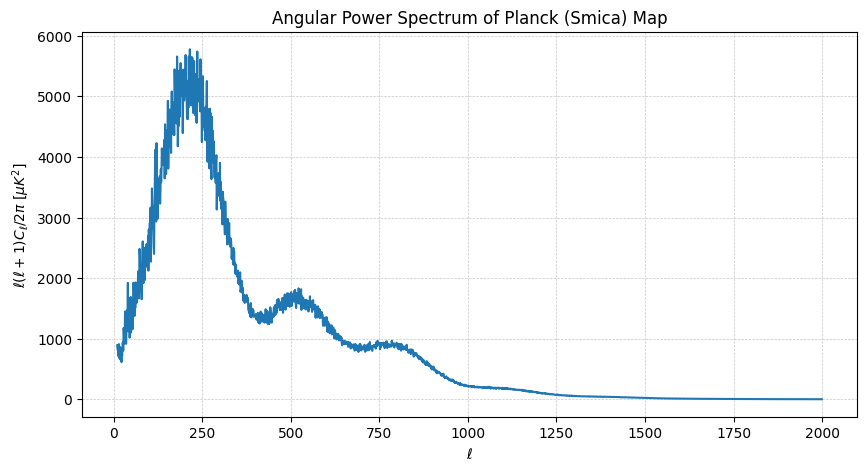

In [ ]:
LMAX = 2000
cl_planck = hp.anafast(Planck_Smica_map,  lmax=LMAX)
ell_planck = np.arange(len(cl_planck))

# hp.write_cl("cl_planck.fits", cl_planck, overwrite=True

# ---- Compute C(theta) ----
psi = np.linspace(0.01, np.pi, 200)  # Angular separation from 0 to π
c_psi = np.zeros_like(psi)

for i, t in enumerate(psi):
    # print(i, t)
    legendre_vals = eval_legendre(ell_planck, np.cos(t))  # P_l(cosθ)
    # print(legendre_vals[0:2])
    c_psi[i] = np.sum((2 * ell_planck+ 1) / (4 * np.pi) * cl_planck * legendre_vals)  # Sum over ell
    # print(i, t,c_psi[i])

# ---- Plot C(psi) ----
plt.figure(figsize=(8, 5))
plt.plot(np.degrees(psi), c_psi, color='b', label=r'$C(\psi)$')
plt.xlabel(r'Angular separation $\psi$ (degrees)')
plt.ylabel(r'$C(\psi)$')
plt.title('Angular Correlation Function $C(\\psi)$')
plt.legend()
plt.grid()
plt.show()



## Calculate Anchored correlation by Angles choosen randomly


Rotated Sky Map 0: alpha=3.107673792151342, beta=5.532121594785941, gamma=1.480715036513888
Rotated Sky Map 50: alpha=1.8530969871085772, beta=3.9819685502460853, gamma=1.1920602503326192
Rotated Sky Map 100: alpha=0.31225977144478856, beta=2.5344176990726117, gamma=1.123333387195855
Rotated Sky Map 150: alpha=4.241186805194448, beta=1.9506868811488058, gamma=1.2246473317749715
Rotated Sky Map 200: alpha=5.6565760786827095, beta=0.4610879864997604, gamma=1.431057793120038
Rotated Sky Map 250: alpha=1.2174500247290774, beta=6.148764702354747, gamma=0.7658463173193601
Rotated Sky Map 300: alpha=2.739044272611676, beta=2.33353625048086, gamma=3.884368813885262
Rotated Sky Map 350: alpha=0.34319887130761284, beta=5.761971636702528, gamma=3.077933214944
Rotated Sky Map 400: alpha=1.6511175606150603, beta=4.348527411136086, gamma=5.827621892625341
Rotated Sky Map 450: alpha=4.074533446376756, beta=0.8198462408465389, gamma=3.5515097425353344
Rotated Sky Map 500: alpha=5.341488774988355, beta

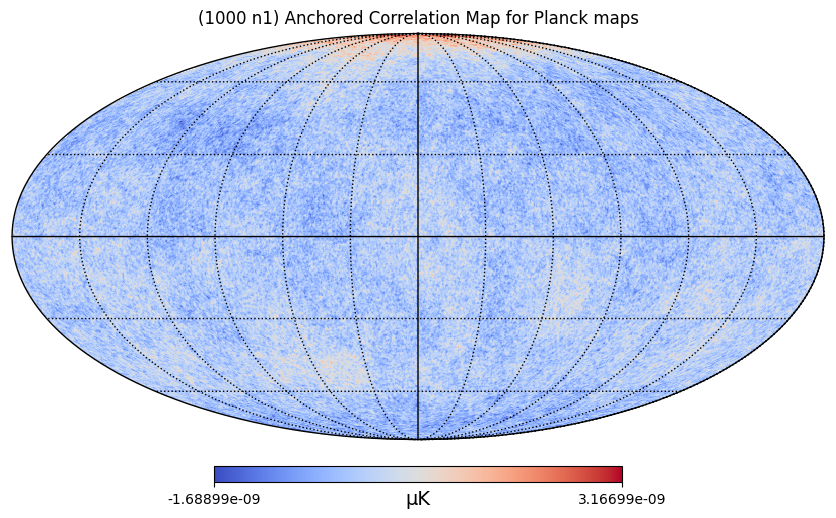

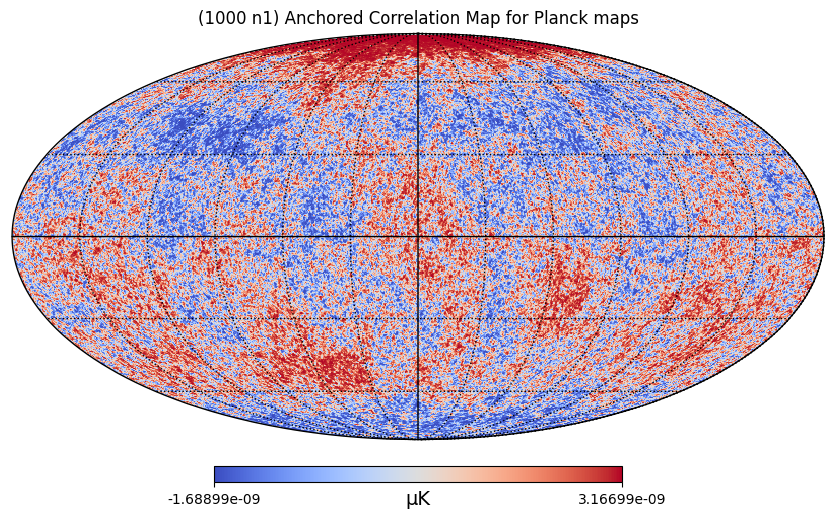

In [ ]:
# Define new NSIDE (lower resolution)
new_nside = 512

# Degrade the map using healpy.ud_grade()
Planck_Smica_map_low = hp.ud_grade(Planck_Smica_map, nside_out=new_nside, power=-2)

n_anchors = int(1000)

alpha = np.random.uniform(0, 2*np.pi, n_anchors)
beta = np.random.uniform(0, 2*np.pi, n_anchors)
gamma = np.random.uniform(0, 2*np.pi, n_anchors)

Anchored_correlation_planck = get_anchored_correlation(Planck_Smica_map_low, alpha, beta, gamma)

# plot the Correlation(psi, varphi) as Healpix map with theta nSI
hp.mollview(Anchored_correlation_planck, title=f"({n_anchors} n1) Anchored Correlation Map for Planck maps", cmap="coolwarm", unit="μK")
hp.graticule()
plt.show()

# plot the Correlation(psi, varphi) as Healpix map with theta nSI
hp.mollview(Anchored_correlation_planck, title=f"({n_anchors} n1) Anchored Correlation Map for Planck maps",norm = "hist", cmap="coolwarm", unit="μK")
hp.graticule()
plt.show()

In [ ]:
# hp.write_map("Anchored_correlation_planck_1024_1000.fits", Anchored_correlation_planck, overwrite=True)

# plot the Correlation as C_001(psi) plot using the Ensemble Averaged correlation map

psi_values, C_001_AA = get_C001_from_maps(Anchored_correlation_planck)

setting the output map dtype to [dtype('float32')]


Number of distinct theta values: 4095
Unique theta values: [7.97359963e-04 1.59472005e-03 2.39208040e-03 ... 3.13920057e+00
 3.13999793e+00 3.14079529e+00]


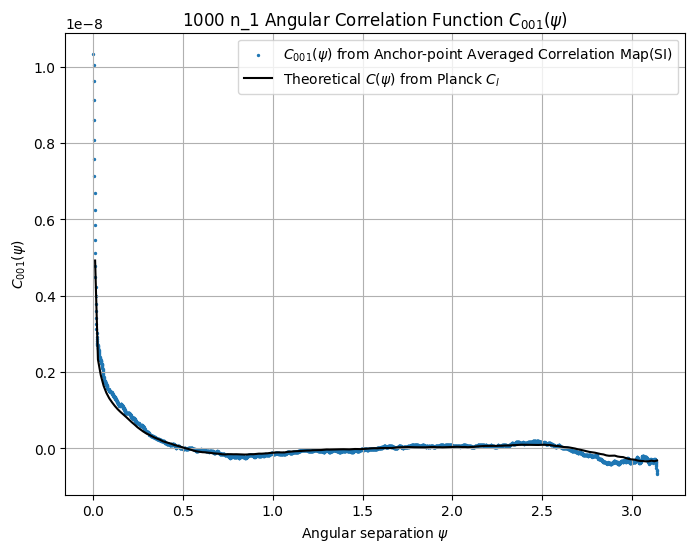

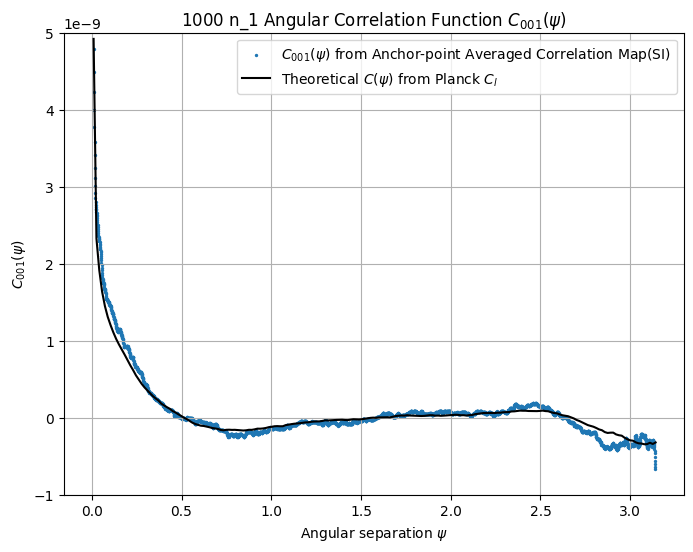

In [ ]:
# normalize it somehow
plt.figure(figsize=(8, 6))
plt.scatter(psi_values, C_001_AA, label=r'$C_{001}(\psi)$ from Anchor-point Averaged Correlation Map(SI)', s =2)
plt.plot(psi, c_psi, color='black', label=r'Theoretical $C(\psi)$ from Planck $C_l$')
plt.xlabel(r'Angular separation $\psi$')
plt.ylabel(r'$C_{001}(\psi)$')
# plt.ylim(-1e-9, 5e-9)
plt.title(r'1000 n_1 Angular Correlation Function $C_{001}(\psi)$')
plt.legend()
plt.grid()
plt.show()


# normalize it somehow
plt.figure(figsize=(8, 6))
plt.scatter(psi_values, C_001_AA, label=r'$C_{001}(\psi)$ from Anchor-point Averaged Correlation Map(SI)', s =2)
plt.plot(psi, c_psi, color='black', label=r'Theoretical $C(\psi)$ from Planck $C_l$')
plt.xlabel(r'Angular separation $\psi$')
plt.ylabel(r'$C_{001}(\psi)$')
plt.ylim(-1e-9, 5e-9)
plt.title(r'1000 n_1 Angular Correlation Function $C_{001}(\psi)$')
plt.legend()
plt.grid()
plt.show()

/tmp/ipykernel_37764/832359995.py:19: RuntimeWarning: divide by zero encountered in divide
  np.arctan(-1/np.tan(phi_anchors)) + np.pi,
/tmp/ipykernel_37764/832359995.py:20: RuntimeWarning: divide by zero encountered in divide
  np.arctan(-1/np.tan(phi_anchors)))


Rotated Sky Map 0: alpha=-2.3137405354141043, beta=-2.4178439477520555, gamma=0.0


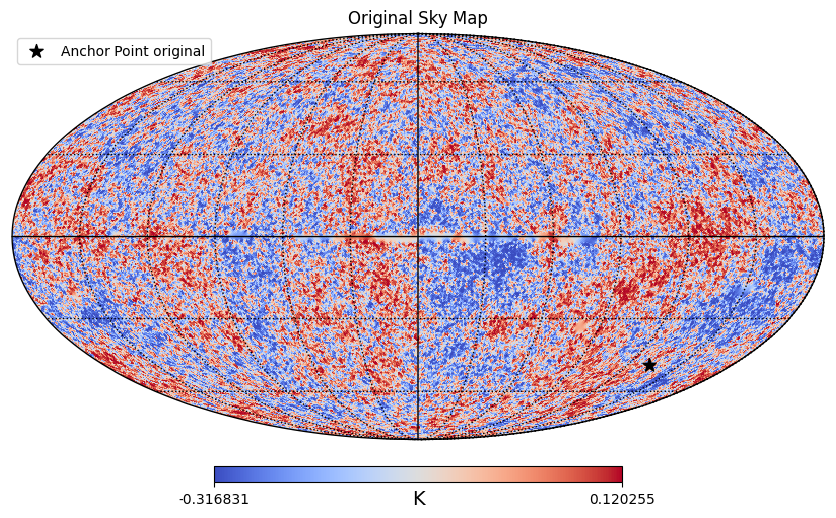

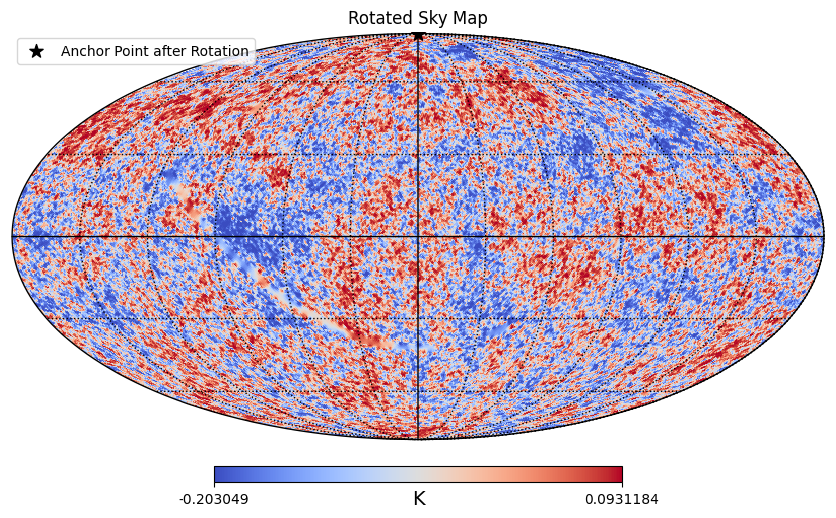

Rotated Sky Map 200: alpha=-0.795732349757941, beta=-2.6519202341677444, gamma=0.0
Rotated Sky Map 400: alpha=0.5399612373357456, beta=-1.4612020708843627, gamma=0.0
Rotated Sky Map 600: alpha=0.05726861608106382, beta=-2.5192241650347724, gamma=0.0
Rotated Sky Map 800: alpha=-2.4973207226778245, beta=-2.2729106024000623, gamma=0.0
Rotated Sky Map 1000: alpha=0.3190680038802134, beta=-1.1121794481956586, gamma=0.0
Rotated Sky Map 1200: alpha=-1.6505633277649514, beta=-1.7806669190576343, gamma=0.0
Rotated Sky Map 1400: alpha=1.7147859900844287, beta=-0.3851081447625733, gamma=0.0
Rotated Sky Map 1600: alpha=-2.4114177985562284, beta=-1.6542264134055116, gamma=0.0
Rotated Sky Map 1800: alpha=0.5497787143782138, beta=-2.5593019174601843, gamma=0.0
Rotated Sky Map 2000: alpha=-1.1388273369263002, beta=-0.3851081447625733, gamma=0.0
Rotated Sky Map 2200: alpha=-2.7059421098302714, beta=-0.9350850413935945, gamma=0.0
Rotated Sky Map 2400: alpha=-0.5338253141842044, beta=-1.9217036703859778,

setting the output map dtype to [dtype('float32')]


Rotated Sky Map 10000: alpha=-3.1109130378320806, beta=-1.9551931012905357, gamma=0.0
 Correlation Map saved as correlation_map_128_10000.fits
Rotated Sky Map 10200: alpha=2.5586799541932495, beta=-1.8234765819369754, gamma=0.0
Rotated Sky Map 10400: alpha=-1.7180584824319196, beta=-1.74352900495937, gamma=0.0
Rotated Sky Map 10600: alpha=2.3868741059500573, beta=-1.4873662401842815, gamma=0.0
Rotated Sky Map 10800: alpha=-0.3190680038802143, beta=-1.8073719376404396, gamma=0.0
Rotated Sky Map 11000: alpha=-1.0185632431560656, beta=-1.8181011428771132, gamma=0.0
Rotated Sky Map 11200: alpha=2.460505183768568, beta=-1.2087735018894246, gamma=0.0
Rotated Sky Map 11400: alpha=2.3812603890241784, beta=-2.5326112613925735, gamma=0.0
Rotated Sky Map 11600: alpha=3.1231848841351653, beta=-1.318116071652818, gamma=0.0
Rotated Sky Map 11800: alpha=-2.840932419164208, beta=-1.47690845168738, gamma=0.0
Rotated Sky Map 12000: alpha=2.7845934884091346, beta=-0.2108936296756696, gamma=0.0
Rotated Sk

setting the output map dtype to [dtype('float32')]


Rotated Sky Map 20000: alpha=-1.7364662518865457, beta=-1.7382444060145859, gamma=0.0
 Correlation Map saved as correlation_map_128_20000.fits
Rotated Sky Map 20200: alpha=-0.632000084608885, beta=-1.1295316602143637, gamma=0.0
Rotated Sky Map 20400: alpha=0.36815538909255374, beta=-2.2260684152958388, gamma=0.0
Rotated Sky Map 20600: alpha=0.4356505437595217, beta=-0.9350850413935945, gamma=0.0
Rotated Sky Map 20800: alpha=-2.3561944901923457, beta=-1.169485889801056, gamma=0.0
Rotated Sky Map 21000: alpha=-0.12271846303085199, beta=-1.0770156486479205, gamma=0.0
Rotated Sky Map 21200: alpha=0.03739991254273556, beta=-0.6829794691165287, gamma=0.0
Rotated Sky Map 21400: alpha=1.2728866786096575, beta=-2.956340362070761, gamma=0.0
Rotated Sky Map 21600: alpha=-1.4542137869155882, beta=-1.6020514152943919, gamma=0.0
Rotated Sky Map 21800: alpha=-1.4899465158569243, beta=-2.704354237123655, gamma=0.0
Rotated Sky Map 22000: alpha=-1.8223691760081417, beta=-2.023612921539822, gamma=0.0
Rot

In [ ]:
np.random.seed(389)

fits_file_path = f'{os.getcwd()}/Data/galactic_output_map_1.fits'
fits_file_path = f'{os.getcwd()}/Data/CMB-Planck_Smica_nosz_map_128_R3.fits'
Planck_Smica_map_1024 = hp.read_map(fits_file_path, field =0)

n_res = 128
n_anchors = int(30000)

# alpha = np.random.uniform(0, 2*np.pi, n_anchors)
# beta = np.random.uniform(0, 2*np.pi, n_anchors)
# gamma = np.random.uniform(0, 2*np.pi, n_anchors)

npix = hp.nside2npix(n_res)
anchor_points = np.random.choice(npix, n_anchors, replace=False)
# theta_anchors, phi_anchors = hp.pix2ang(n_res, anchor_points, lonlat = False)  # Get anchor points

# print(f"Anchor points for nside = {n_res}, npix = {npix}: \n{anchor_points}")
# print(f"Theta values: {theta_anchors}")
# print(f"Phi values: {phi_anchors}")

# Anchored_correlation_planck2 = get_anchored_correlation(Planck_Smica_map_1024, alpha, beta, gamma)
Anchored_correlation_planck2 = get_anchored_correlation2(Planck_Smica_map_1024, anchor_points)


# plot the Correlation as C_001(psi) plot using the Ensemble Averaged correlation map

psi_values2, C_001_AA2 = get_C001_from_maps(Anchored_correlation_planck2)

In [ ]:
output_filename = f"./output_FITS/Anchored_correlation_map_{n_res}_{n_anchors}(rndm).fits"
hp.write_map(output_filename, Anchored_correlation_planck2, overwrite=True)
print(f" Correlation Map saved as {output_filename}")

setting the output map dtype to [dtype('float32')]


 Correlation Map saved as ./output_FITS/Anchored_correlation_map_128_30000(rndm).fits


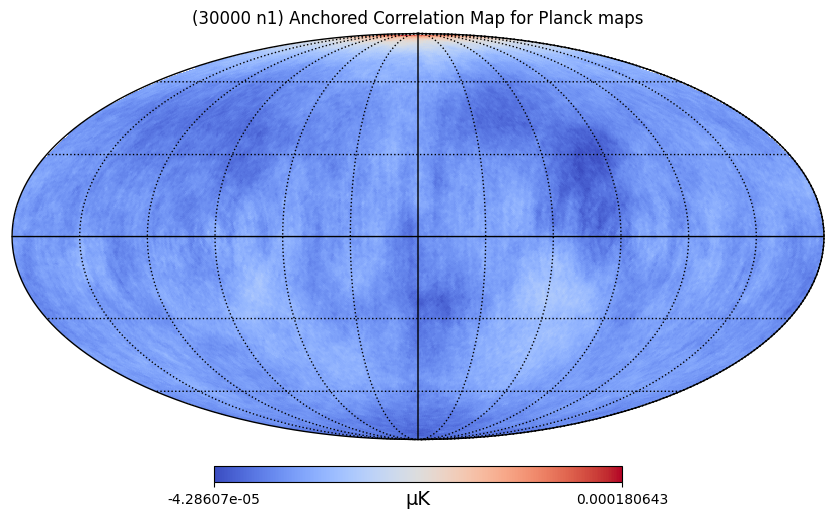

NameError: name 'psi_values2' is not defined

<Figure size 800x600 with 0 Axes>

In [ ]:
# plot the Correlation(psi, varphi) as Healpix map with theta nSI
n_anchors =30000
Anchored_correlation_planck2 = hp.read_map(f"./output_FITS/Anchored_correlation_map_128_30000(rndm).fits")
hp.mollview(Anchored_correlation_planck2, title=f"({n_anchors} n1) Anchored Correlation Map for Planck maps", cmap="coolwarm", unit="μK", norm ='hist')
hp.graticule()
plt.show()

# normalize it somehow
plt.figure(figsize=(8, 6))
plt.scatter(psi_values2, C_001_AA2*1e-5, label=r'$C_{001}(\psi)$ from Spatially Averaged Correlation Map(SI)', s =2)
plt.plot(psi, c_psi, color='black', label=r'Theoretical $C(\psi)$ from Planck $C_l$')
plt.xlabel(r'Angular separation $\psi$')
plt.ylabel(r'$C_{001}(\psi)$')
# plt.ylim(-1.5e-9, 5e-9)
plt.title('Angular Correlation Function $C_{001}(\psi)$')
plt.legend()
plt.grid()
plt.show()

### for the 2048 map

In [ ]:
# Path to the FITS file
n_res = 128
fits_file_path = f'{os.getcwd()}/Data/CMB-Planck_Smica_nosz_map_128_R3.fits'
# fits_file_path = f'{os.getcwd()}/Data/galactic_output_map_1.fits'
Planck_Smica_map_2048 = hp.read_map(fits_file_path, field =0)

n_anchors = int(30001)
print(f"Random n1 for planck map, n_anchors = {n_anchors}")
alpha = np.random.uniform(0, 2*np.pi, n_anchors)
beta = np.random.uniform(0, 2*np.pi, n_anchors)
gamma = np.random.uniform(0, 2*np.pi, n_anchors)

print("Computing Anchored Correlation Map for Planck map")
Anchored_correlation_planck3 = get_anchored_correlation(Planck_Smica_map_2048, alpha, beta, gamma)

# # hp.write_map("Anchored_correlation_planck2048.fits", Anchored_correlation_planck3, overwrite=False)

# plot the Correlation as C_001(psi) plot using the Ensemble Averaged correlation map
psi_values3, C_001_AA3 = get_C001_from_maps(Anchored_correlation_planck3)


Random n1 for planck map, n_anchors = 30001
Computing Anchored Correlation Map for Planck map
Rotated Sky Map 0: alpha=5.481006755575827, beta=5.40603706378239, gamma=4.914123032740234


KeyboardInterrupt: 

In [ ]:
# Anchored_correlation_planck3 = hp.read_map(f"{os.getcwd()}/output_FITS/Anchored_correlation_planck_2048.fits") # Read the map
# plot the Correlation as C_001(psi) plot using the Ensemble Averaged correlation map
# psi_values3, C_001_AA3 = get_C001_from_maps(Anchored_correlation_planck3)

setting the output map dtype to [dtype('float32')]


 Correlation Map saved as ./output_FITS/Anchored_correlation_map_128_30000.fits


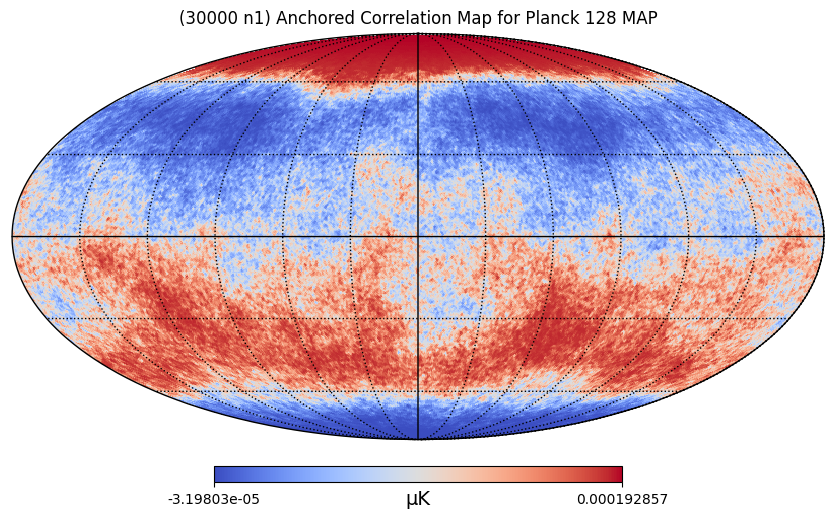

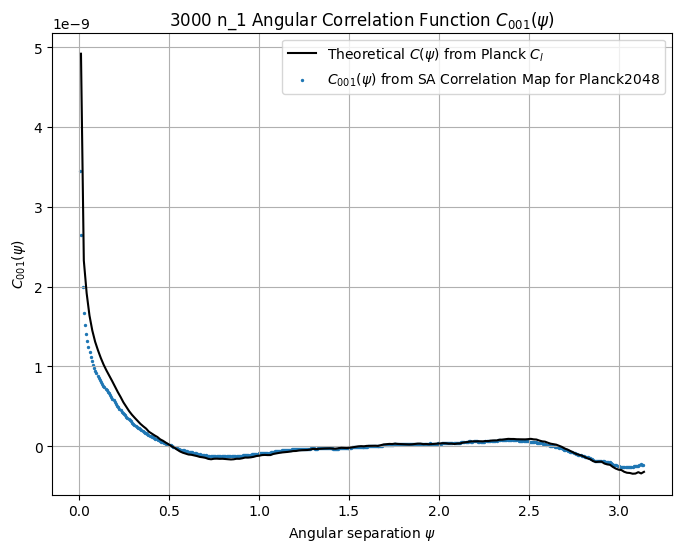

In [ ]:
output_filename = f"./output_FITS/Anchored_correlation_map_{n_res}_{n_anchors}.fits"
hp.write_map(output_filename, Anchored_correlation_planck3, overwrite=True)
print(f" Correlation Map saved as {output_filename}")

# plot the Correlation(psi, varphi) as Healpix map with theta nSI
hp.mollview(Anchored_correlation_planck3, title=f"({n_anchors} n1) Anchored Correlation Map for Planck 128 MAP", norm ="hist", cmap="coolwarm", unit="μK")
hp.graticule()
plt.show()



# normalize it somehow
plt.figure(figsize=(8, 6))
plt.plot(psi, c_psi, color='black', label=r'Theoretical $C(\psi)$ from Planck $C_l$')
plt.scatter(psi_values3, C_001_AA3*1e-5, label=r'$C_{001}(\psi)$ from SA Correlation Map for Planck2048', s =2)
plt.xlabel(r'Angular separation $\psi$')
plt.ylabel(r'$C_{001}(\psi)$')
# plt.ylim(-1e-9, 5e-9)
plt.title(r'3000 n_1 Angular Correlation Function $C_{001}(\psi)$')
plt.legend()
plt.grid()
plt.show()

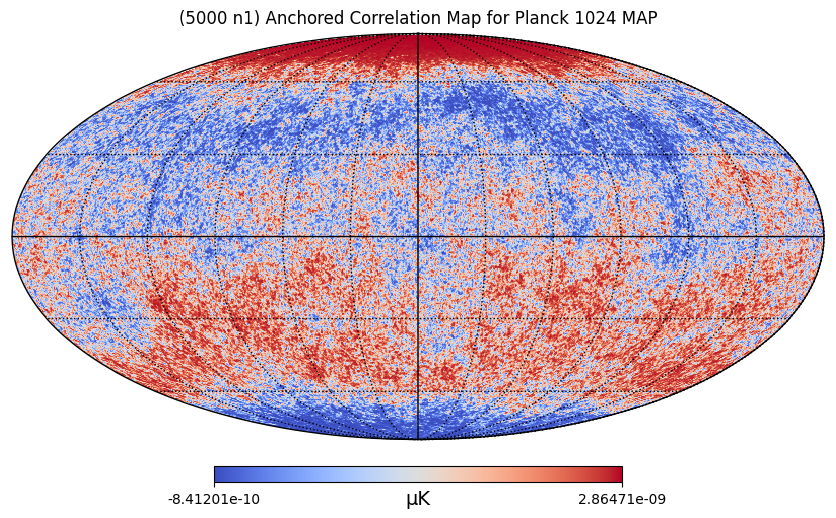

In [ ]:
corr_map = hp.read_map("output_FITS/Anchored_correlation_planck_1024_5000.fits", field =0)

hp.mollview(corr_map, title="(5000 n1) Anchored Correlation Map for Planck 1024 MAP", norm ="hist", cmap="coolwarm", unit="μK")
hp.graticule()
plt.show()



### -----------------

In [ ]:
# import multiprocessing as mp

# def compute_partial_correlation(args):
#     """ Compute C_001(psi, phi) correlation function for a subset of rotations. """
#     map, alpha_subset, beta_subset, gamma_subset = args
#     Anchored_correlation = np.zeros_like(map)
#     nside = hp.get_nside(map)

#     for i in range(len(gamma_subset)):
#         print(f"Rotated Sky Map {i}: alpha={alpha_subset[i]}, beta={beta_subset[i]}, gamma={gamma_subset[i]}")
#         rotation = hp.rotator.Rotator(rot=[alpha_subset[i], beta_subset[i], gamma_subset[i]], deg=False)
#         rotated_map = rotation.rotate_map_pixel(map)
#         T_001 = rotated_map[hp.ang2pix(nside, 0, 0)]
#         Anchored_correlation += T_001 * rotated_map

#     return Anchored_correlation

# def get_anchored_correlation_parallel(map, alpha, beta, gamma, n_processes=5):
#     """ Parallelized computation of the C_001(psi, phi) correlation function. """
#     n_anchors = len(gamma)
#     chunk_size = n_anchors // n_processes

#     # Split the rotations into chunks
#     chunks = [(map, alpha[i:i+chunk_size], beta[i:i+chunk_size], gamma[i:i+chunk_size]) 
#               for i in range(0, n_anchors, n_processes)]

#     # Run parallel processing
#     with mp.Pool(n_processes) as pool:
#         results = pool.map(compute_partial_correlation, chunks)

#     # Sum the results from all processes
#     Anchored_correlation = sum(results) / n_anchors

#     return Anchored_correlation

# # Number of samples
# n_anchors = 100  
# # n_processes = mp.cpu_count()  # Use all available CPUs

# # Random rotations
# alpha = np.random.uniform(0, 2*np.pi, n_anchors)
# beta = np.random.uniform(0, 2*np.pi, n_anchors)
# gamma = np.random.uniform(0, 2*np.pi, n_anchors)

# # Compute the correlation in parallel
# Anchored_correlation_planck2 = get_anchored_correlation_parallel(Planck_Smica_map, alpha, beta, gamma, 5)

In [ ]:
# n_anchors = int(1000)

# alpha = np.random.uniform(0, 2*np.pi, n_anchors)
# beta = np.random.uniform(0, 2*np.pi, n_anchors)
# gamma = np.random.uniform(0, 2*np.pi, n_anchors)

# Anchored_correlation_planck = get_anchored_correlation_parallel(Planck_Smica_map, alpha, beta, gamma)

# # plot the Correlation(psi, varphi) as Healpix map with theta nSI
# hp.mollview(Anchored_correlation_planck2, title=f"({n_anchors} n1) Anchored Correlation Map for Planck maps", cmap="coolwarm", unit="μK")
# hp.graticule()
# plt.show()

In [ ]:
# %%cython
# # Fix: Disable deprecated NumPy API
# # Must be before any NumPy imports!
# cdef extern from *:
#     """
#     #define NPY_NO_DEPRECATED_API NPY_1_7_API_VERSION
#     """
#     pass

# import numpy as np
# cimport numpy as np
# from healpy import Rotator, pix2ang
# from libc.math cimport sin, cos

# def fast_rotate_map(np.ndarray[np.float64_t, ndim=1] map, double alpha, double beta, double gamma):
#     """
#     Rotate a HEALPix map using Euler angles alpha, beta, gamma.
    
#     Parameters:
#         map : 1D numpy array (HEALPix map)
#         alpha, beta, gamma : Rotation angles in radians
    
#     Returns:
#         rotated_map : 1D numpy array (rotated HEALPix map)
#     """
#     cdef int nside = int(np.sqrt(len(map) / 12))
#     cdef int npix = len(map)
#     cdef np.ndarray[np.float64_t, ndim=1] rotated_map = np.zeros_like(map)
#     cdef object rotation = Rotator(rot=[alpha, beta, gamma], deg=False)  # ✅ Fix here
#     cdef double theta, phi
#     cdef np.ndarray[np.float64_t, ndim=1] vec, vec_out  # ✅ Use NumPy arrays

#     for pix in range(npix):
#         if pix % 1000 == 0:
#             print(f"Rotating pixel {pix} / {npix}")
#         theta, phi = pix2ang(nside, pix)
#         vec = np.array([sin(theta) * cos(phi), sin(theta) * sin(phi), cos(theta)])
#         vec_out = np.array(rotation(vec))  # ✅ Fix type error
#         rotated_map[pix] = vec_out[2]  # Example: store rotated Z-component

#     return rotated_map


# Path to the FITS file


# Use this instead of hp.rotator
# Planck_Smica_map_1024 = Planck_Smica_map_1024.astype('<f4')  # Convert to little-endian float32

# Rotate the map
# Planck_Smica_map_1024 = Planck_Smica_map_1024.astype(np.float32).byteswap()

# rotated_map = fast_rotate_map(Planck_Smica_map_1024.astype(np.float64), 1.0, 2.0, 3.0)